In [2]:
# Importing Libraries:
import os
import cv2
import numpy as np
import librosa
import librosa.display
import pandas as pd
from scipy.spatial.distance import cosine, euclidean
from fastdtw import fastdtw
from scipy.signal import find_peaks
import ffmpeg
import matplotlib.pyplot as plt

In [3]:
def plot_spectrogram(file_path):
    # Load the audio file
    y, sr = librosa.load(file_path)
    # Generate the spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    # Plot the spectrogram
    librosa.display.specshow(D, y_axis='log', x_axis='time')
    plt.title('Power spectrogram')
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.show()

In [4]:
def extract_video_positions(video_path):
    cap = cv2.VideoCapture(video_path)
    positions = []
    frame_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        lower_blue = np.array([110, 50, 50])
        upper_blue = np.array([130, 255, 255])
        mask = cv2.inRange(hsv, lower_blue, upper_blue)

        contours, _ = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            c = max(contours, key=cv2.contourArea)
            M = cv2.moments(c)
            if M["m00"] != 0:
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                positions.append([frame_count, cX, cY])

        frame_count += 1

    cap.release()

    # Convert to DataFrame
    df = pd.DataFrame(positions, columns=["Frame", "X", "Y"])

    return df

In [5]:
def plot_video_positions_X(df):
    plt.figure(figsize=(8, 6))
    plt.plot(df["Frame"], df["X"], marker="o", linestyle="-", color="b", label="Object Path")
    plt.xlabel("Frame")
    plt.ylabel("X Position")
    plt.title("Object Trajectory in Video") 
    plt.legend()
    plt.grid(True)
    plt.show()

In [6]:
def plot_video_positions_Y(df):
    plt.figure(figsize=(8, 6))
    plt.plot(df["Frame"], df["Y"], marker="o", linestyle="-", color="b", label="Object Path")
    plt.xlabel("Frame")
    plt.ylabel("Y Position")
    plt.title("Object Trajectory in Video")
    plt.gca().invert_yaxis()
    plt.legend()
    plt.grid(True)
    plt.show()

In [7]:
def find_valleys_y(df):
    valleys, _ = find_peaks(-df["Y"])

    filtered_valleys = []
    for i in range(len(valleys)):
        if i == 0:
            filtered_valleys.append(valleys[i])
        elif valleys[i] - valleys[i-1] > 50:
            filtered_valleys.append(valleys[i])

    valley_frames = df["Frame"].iloc[filtered_valleys].tolist()

    return valley_frames, filtered_valleys

In [8]:
def plot_valleys_y(df, valley_frames):
    plt.figure(figsize=(8, 6))
    plt.plot(df["Frame"], df["Y"], marker="o", linestyle="-", color="b", label="Object Path")
    plt.scatter(valley_frames, df["Y"].iloc[valley_frames], color="r", label="Valleys")
    plt.xlabel("Frame")
    plt.ylabel("Y Position")
    plt.title("Object Trajectory in Video")
    plt.gca().invert_yaxis()
    plt.legend()
    plt.grid(True)
    plt.show()

In [9]:
def find_peaks_valleys_x(df):
    peaks, _ = find_peaks(df["X"])
    valleys, _ = find_peaks(-df["X"])

    filtered_vals = []
    for i in range(len(peaks)):
        if i == 0:
            filtered_vals.append(peaks[i])
        elif peaks[i] - peaks[i-1] > 50:
            filtered_vals.append(peaks[i])
    
    for i in range(len(valleys)):
        if i == 0:
            filtered_vals.append(valleys[i])
        elif valleys[i] - valleys[i-1] > 50:
            filtered_vals.append(valleys[i])
    
    frames_x = df["Frame"].iloc[filtered_vals].tolist()

    return frames_x, filtered_vals

In [10]:
def plot_peaks_and_valleys_x(df, frames_x):
    plt.figure(figsize=(8, 6))
    plt.plot(df["Frame"], df["X"], marker="o", linestyle="-", color="b", label="Object Path")
    plt.scatter(frames_x, df["X"].iloc[frames_x], color="r", label="Peaks and Valleys")
    plt.xlabel("Frame")
    plt.ylabel("X Position")
    plt.title("Object Trajectory in Video")
    plt.legend()
    plt.grid(True)
    plt.show()

In [11]:
def get_total_frames(valley_frames, frames_x):
    total_frames = valley_frames + frames_x
    total_frames.sort()
    return total_frames

In [ ]:
def extract_spectrogram_spikes(audio_path, fps=60.0):
    # Load audio
    y, sr = librosa.load(audio_path)
    
    # Compute spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    
    # Get energy over time (sum across frequency bins)
    energy = np.mean(D, axis=0)
    threshold = np.percentile(energy, 90)

    # Find spikes (peaks in energy)
    peaks, _ = find_peaks(energy, height=threshold, distance=5)  # Adjust height threshold as needed

    # Convert spectrogram time to video frame indices
    duration = librosa.get_duration(y=y, sr=sr)
    time_indices = peaks * (duration / D.shape[1])  # Convert spectrogram index to seconds
    frame_indices = np.round(time_indices * fps).astype(int)  # Convert seconds to frame indices
    
    return frame_indices.tolist()

In [13]:
# Example of this:
df = extract_video_positions(r"C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\video_only\video_only_ID_1.mp4")
valley_frames, filtered_valleys = find_valleys_y(df)
valleys_x, filtered_vals = find_peaks_valleys_x(df)


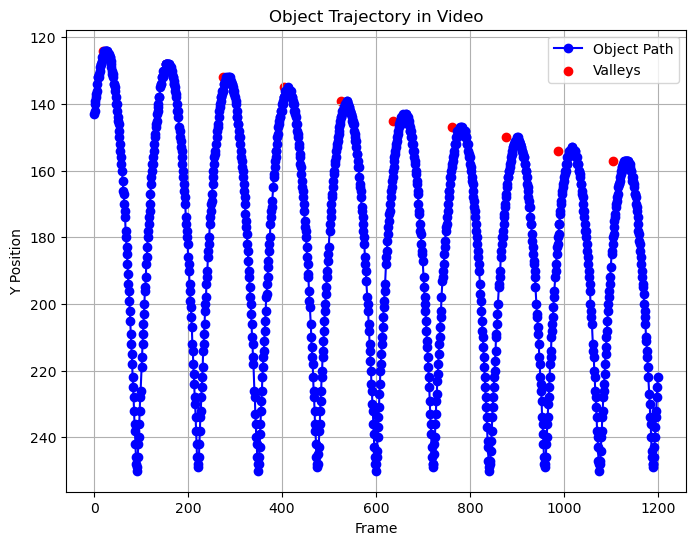

In [16]:
plot_valleys_y(df, filtered_valleys)

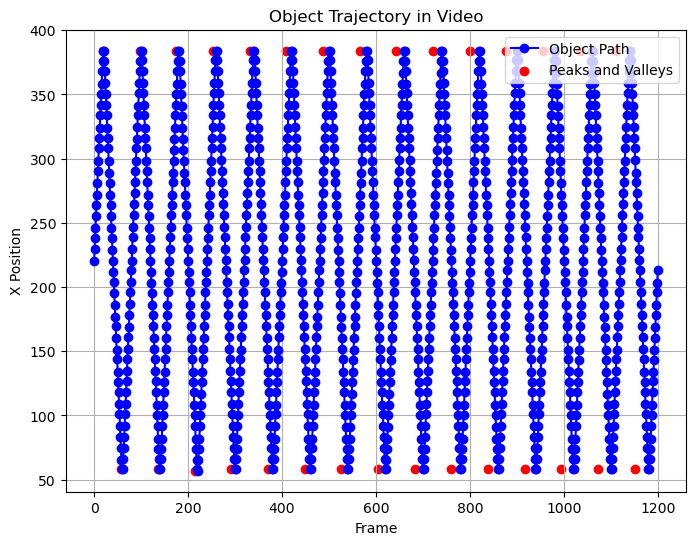

In [17]:
plot_peaks_and_valleys_x(df, filtered_vals)

In [19]:
frames = extract_spectrogram_spikes(r"C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only\audio_only_ID_1.wav")

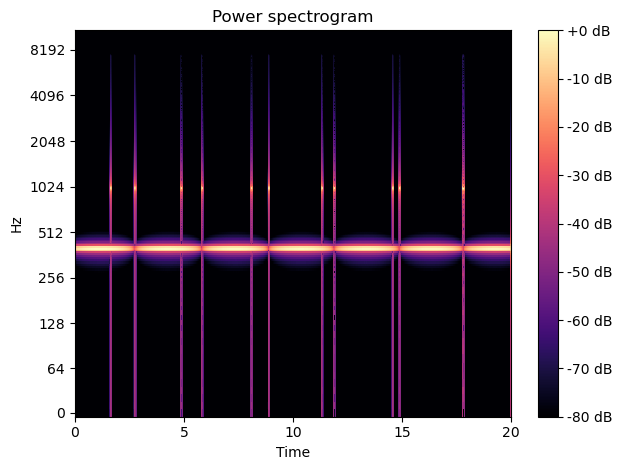

In [20]:
plot_spectrogram(r"C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only\audio_only_ID_1.wav")

In [21]:
audio_dir = r"C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only"
video_dir = r"C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\video_only"
audio_files = [f for f in os.listdir(audio_dir) if f.endswith(".wav")]
#video_files = [f for f in os.listdir(video_dir) if f.endswith(".mp4")]

matches = []
used_audio_files = set()

for i in range(1, 46):
    video_file = os.path.join(video_dir, f"video_only_ID_{i}.mp4")
    df = extract_video_positions(video_file)
    valley_frames, filtered_valleys = find_valleys_y(df)
    frames_x, filtered_vals = find_peaks_valleys_x(df)

    total_frames = get_total_frames(valley_frames, frames_x)

    min_diff = float("inf")
    best_match = None
    best_match_len = -1

    for audio_files in os.listdir(audio_dir):
        if audio_files in used_audio_files:
            continue

        audio_file = os.path.join(audio_dir, audio_files)
        spikes = extract_spectrogram_spikes(audio_file)

        if len(spikes) + 1 == len(total_frames):
            distance, _ = fastdtw(spikes, total_frames)
            if distance < min_diff:
                min_diff = distance
                best_match = audio_file
                best_match_len = len(spikes)
    
    if best_match:
        print(f"Best match for video_only_ID_{i}.mp4 is {best_match}")
        matches.append((best_match, f"video_only_ID_{i}.mp4"))
        used_audio_files.add(best_match)


matches_df = pd.DataFrame(matches, columns=["AUDIO", "VIDEO"])

Best match for video_only_ID_1.mp4 is C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only\audio_only_ID_45.wav
Best match for video_only_ID_2.mp4 is C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only\audio_only_ID_1.wav
Best match for video_only_ID_3.mp4 is C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only\audio_only_ID_24.wav
Best match for video_only_ID_4.mp4 is C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only\audio_only_ID_24.wav
Best match for video_only_ID_5.mp4 is C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only\audio_only_ID_30.wav
Best match for video_only_ID_7.mp4 is C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only\audio_only_ID_3.wav
Best match for video_only_ID_8.mp4 is C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only\audio_only_ID_18.wav
Best match for video_only_ID_9.mp4 is C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only\audio_only_ID_3.wav
Best match for video_only_ID_10.mp4

In [22]:
print(len(matches_df["AUDIO"].unique()))

19


In [18]:
def merge_video_audio(video_path, audio_path, output_path):
    """
    Merges the given video with the best-matching audio.
    """
    input_video = ffmpeg.input(video_path)
    input_audio = ffmpeg.input(audio_path)
    
    (
        ffmpeg
        .output(input_video, input_audio, output_path, vcodec="copy", acodec="aac", strict="experimental")
        .run(overwrite_output=True)
    )

In [34]:
matches_df.head()

,AUDIO,VIDEO
0,C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dat...,video_only_ID_1.mp4
1,C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dat...,video_only_ID_2.mp4
2,C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dat...,video_only_ID_3.mp4
3,C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dat...,video_only_ID_4.mp4
4,C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dat...,video_only_ID_5.mp4


In [33]:
matches_df.to_csv("matches.csv", index=False)

In [39]:
merge_video_audio(r"C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\video_only\video_only_ID_3.mp4", r"C:\Users\ASUS\MMDP\Task_Search_For_A_Match\dataset\audio_only\audio_only_ID_24.wav", "output.mp4")